In [1]:
from DataLoader import DataLoader
from tara_preprocessing import get_just_ecog_data,get_electrode_normalized_loc,clip_time_series
from tara_preprocessing import remove_duplicates, preprocessing,apply_car_function
from noah_production_funcs_2 import get_1_patient_locations,sample_iterators,built_iterator_list
from pathlib import Path
import seaborn as sns
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm
from torch.nn import Linear,LeakyReLU
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GCNConv,BatchNorm
from torch_geometric.nn import global_mean_pool,global_add_pool

### Load in the data

In [2]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
ecogs = clip_time_series(ecogs)
print("Time series clipped")
ecogs_no_dups,xyz_no_dups = remove_duplicates(ecogs,xyz)
print('Removed duplicate electrodes')
xyz_clean, ecogs_cleaned = preprocessing(ecogs_no_dups,xyz_no_dups,notch_size=.05)
print("Done Preprocessing")

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

### Turns into z score

In [3]:
ecogs_z = []
for pat in ecogs_cleaned:
    mean = pat.mean(axis=0,keepdims=True)
    std = pat.mean(axis=0,keepdims=True)
    temp = (pat-mean)/std
    ecogs_z.append(temp)
ecogs_cleaned = ecogs_z

### Model

In [6]:
win_size = 100
class GCNv2(torch.nn.Module):
    def __init__(self, hidden_channels,num_features_per_node,output_size):
        super(GCNv2, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(num_features_per_node, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.conv4 = GCNConv(hidden_channels, hidden_channels)
        self.batching = BatchNorm(hidden_channels)
        self.lin = Linear(hidden_channels, output_size)

    def forward(self, x, edge_index,weights,batch=None):
        x = self.conv1(x, edge_index,weights)
        x = self.batching(x)
        x = F.relu(x)
                      
        x = self.conv2(x, edge_index,weights)
        x = self.batching(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index,weights)
        x = self.batching(x)
        x = F.relu(x)
        
        x = global_mean_pool(x, batch).squeeze()
        x = self.lin(x)
        
        return x
model = GCNv2(hidden_channels=60,num_features_per_node=win_size,output_size=win_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0000001)
loss_func = torch.nn.MSELoss()
model

GCNv2(
  (conv1): GCNConv(100, 60)
  (conv2): GCNConv(60, 60)
  (conv3): GCNConv(60, 60)
  (conv4): GCNConv(60, 60)
  (batching): BatchNorm(60, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lin): Linear(in_features=60, out_features=100, bias=True)
)

### Training

If your interested in the implementation of: built_iterator_list or of: sample_iterators, go check out the file 'noah_production_funcs_2.py'

In [7]:
batch_loss_list = []
epoch_loss_list = []
big_loss_list = []
epoch_loss = 0
epoch_counter = 0
batch_loss = 0
batch_counter = 0

n_epochs = 2
batch_size = 500
#for each epoch
optimizer.zero_grad()
for epoch in range(n_epochs): 
    #build the list of iterators, one for each patient
    iterators = built_iterator_list(ecogs_cleaned,xyz_clean,win_size=win_size,safety_size = 200,k = 10,max_data_points = 10000000)
    #randomly choose from one of the iterators
    for point in sample_iterators(iterators):
        #get model data
        edges = torch.tensor(point['edges'].T)
        edge_weights = torch.tensor(point['weights'],dtype=torch.float32)
        features = torch.tensor(point['features'],dtype=torch.float32)            
        y = torch.tensor(point['target'],dtype=torch.float32)
        #forward pass
        
        y_pred = model(features,edges,edge_weights)
        loss = loss_func(y_pred,y)
        loss.backward()
        #record loss
        batch_loss+=loss.detach()
        epoch_loss+=loss.detach()
        epoch_counter +=1
        if batch_counter == batch_size: #if we get enough for the batch, 
            optimizer.step() #apply grad step
            #note down loss information
            batch_loss_list.append(batch_loss/batch_size)
            big_loss_list.append(loss.detach())
            print(f"Batch Loss:{batch_loss/batch_size}")
            batch_counter = 0  
            batch_loss = 0
            optimizer.zero_grad()
        else:
            batch_counter+=1
    epoch_loss_list.append(epoch_loss/epoch_counter)
    print(f"Epoch:{epoch} Loss:{epoch_loss/epoch_counter}")
    epoch_counter = 0
    epoch_loss = 0

Batch Loss:4576170.5
Batch Loss:17043052.0
Batch Loss:6390661.5
Batch Loss:6736723.5
Batch Loss:22300736.0
Batch Loss:17314140.0
Batch Loss:10840153.0
Batch Loss:13374782.0
Batch Loss:24311790.0
Batch Loss:30228680.0
Batch Loss:10341369.0
Batch Loss:28586704.0
Batch Loss:18581602.0
Batch Loss:25273256.0
Batch Loss:19246600.0
Batch Loss:17755336.0
Batch Loss:28348296.0
Batch Loss:16505548.0
Batch Loss:22373426.0
Batch Loss:20917138.0
Batch Loss:22044804.0
Batch Loss:21050120.0
Batch Loss:62150516.0
Batch Loss:75637024.0
Batch Loss:33402958.0
Batch Loss:46682796.0
Batch Loss:15317442.0
Batch Loss:20210264.0
Batch Loss:14242438.0
Batch Loss:22346562.0
Batch Loss:11880614.0
Batch Loss:13926985.0
Batch Loss:29507436.0
Batch Loss:20783784.0
Batch Loss:18624550.0
Batch Loss:15961433.0
Batch Loss:45811676.0
Batch Loss:24267024.0
Batch Loss:38196008.0
Batch Loss:13791934.0
Batch Loss:26693266.0
Batch Loss:68776984.0
Batch Loss:80870208.0
Batch Loss:27718600.0
Batch Loss:28429060.0
Batch Loss:22

### Loss per epoch

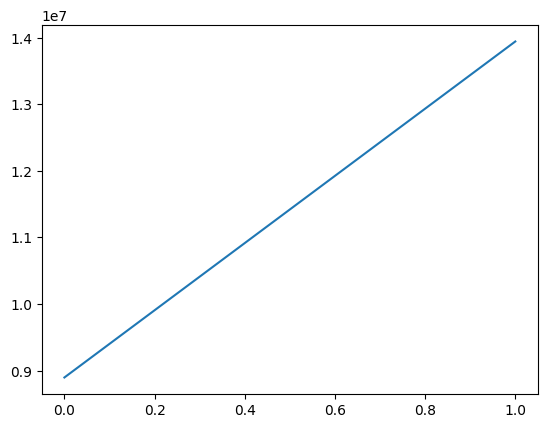

In [8]:
plt.plot(epoch_loss_list)

### Loss per batch

In [ ]:
plt.semilogy(batch_loss_list) #semilogy

### All loss

In [ ]:
plt.semilogy(big_loss_list)

# Ignore everything below this, its iralvent

In [ ]:
# first entire of channel_list mush be: (num_features_per_node, X) where X is whaterever you want
class GCN(torch.nn.Module):
    def __init__(self,output_size,channel_list):
        super(GCN, self).__init__()
        self.blocks = torch.nn.ModuleList([
            torch_geometric.nn.Sequential(
                GCNConv(chan[0], chan[1]),
                BatchNorm(chan[1]),
                torch.nn.Sigmoid(),#torch.nn.Tanh(),
            ) for chan in channel_list
        ])
        self.lin_out = torch.nn.Linear(channel_list[-1][1], output_size) 

    def forward(self, x, edge_index, weights ,batch=None):
        for block in self.blocks:
            x = block(x,edge_index,weights)
        x = global_add_pool(x, batch).squeeze()
        return self.out(x)
#layers = [[win_size,700],[700,500],[500,200],[200,400],[400,500],[500,650]]
#model = GCN(output_size=win_size,channel_list=layers)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.000005)
loss_func = torch.nn.MSELoss()
model

shuffle the patient order

add batching of whatever size 100 at start 

more then one pass through the whole date

smaller learning rate mabye?

In [ ]:
loss_list = []
big_loss = []
batch_size = 200
batch_counter = 0
n_epochs = 30
for epoch in range(n_epochs):
    epoch_loss = 0
    count = 0
    for pat_index in range(len(ecogs_cleaned)): #for each patient
        pat_locs = get_1_patient_locations(pat_index,ecogs_cleaned,xyz_clean)
        
        desired_iter_per_node = ecogs_cleaned[pat_index].shape[0]/win_size - safety_size #timeseries length over window size with a little bit of wiggle room for safety
        pat_num_nodes = ecogs_cleaned[pat_index].shape[1]

        list_held = np.random.randint(low=0,high=pat_num_nodes-1,size=int(pat_num_nodes/factor_held_out))
        #print(list_held)
        loader = DataLoader(limit=max_data_points,
                            patient=pat_index,
                            window_size=800,
                            ecogs=ecogs_cleaned,
                            desired_node_iters=desired_iter_per_node,
                            elecs_to_hold=list_held,
                            xyz=pat_locs,
                            k=k)
        for point in loader:
            # point is a dictionary with the following entires:
            # point['edges'] returns the edges matrix
            # point['weights'] returns the edge weights matrix
            # point['features'] returns the matrix of node features
            # point['targets'] returns the held out electrode window to compare to
            ########### PUT YOUR TRAINING HERE ###########
            edges = torch.tensor(point['edges'].T)
            edge_weights = torch.tensor(point['weights'],dtype=torch.float32)

            features = torch.tensor(point['features'],dtype=torch.float32)
            
            y = torch.tensor(point['target'],dtype=torch.float32)
        
            optimizer.zero_grad()
            y_pred = model(features,edges,edge_weights)
            loss = loss_func(y_pred,y)
            loss.backward()
            epoch_loss+=loss.detach()
            count+=1
            if batch_counter == batch_size:
                optimizer.step()
                big_loss.append(loss.detach())
                #print("We have taken a batch step")
                print(loss.detach())
                batch_counter == 0  
            else:
                batch_counter+=1
    epoch_loss = epoch_loss / count
    count = 0
    print(f"Epoch:{epoch} Loss:{epoch_loss}")
    loss_list.append(epoch_loss)
        

In [ ]:
plt.semilogy(loss_list) #15000:

In [ ]:
'''
iterators = []
batch_size = 200
win_size = 800
safety_size = 200
x = 0
k = 10 #number of neareest neighbors for making the graph
max_data_points = 10000000
factor_held_out = 6 #ie number held out is num_nodes / factor_held_out, rounded to nearest int, so bigger factor_held_out means less held out
for pat_index in range(len(ecogs_cleaned)): #for each patient
    pat_locs = get_1_patient_locations(pat_index,ecogs_cleaned,xyz_clean)    
    desired_iter_per_node = ecogs_cleaned[pat_index].shape[0]/win_size - safety_size #timeseries length over window size with a little bit of wiggle room for safety
    pat_num_nodes = ecogs_cleaned[pat_index].shape[1]
    list_held = np.random.randint(low=0,high=pat_num_nodes-1,size=int(pat_num_nodes/factor_held_out))

    loader = DataLoader(limit=max_data_points,
                        patient=pat_index,
                        window_size=win_size,
                        ecogs=ecogs_cleaned,
                        desired_node_iters=desired_iter_per_node,
                        elecs_to_hold=list_held,
                        xyz=pat_locs,
                        k=k)
    iterators.append(loader)



def sample_iterators(iterators):
    """Randomly sample from multiple iterators until all are exhausted."""
    # Wrap each iterator to track exhaustion
    active = list(iterators)
    buffers = [None] * len(active)
    exhausted = [False] * len(active)

    def try_advance(i):
        try:
            buffers[i] = next(active[i])
            return True
        except StopIteration:
            exhausted[i] = False
            return False

    # Prime each iterator
    live_indices = [i for i in range(len(active)) if try_advance(i)]

    while live_indices:
        # Pick a random live iterator
        idx = random.choice(live_indices)
        yield buffers[idx]

        # Advance it; remove if exhausted
        if not try_advance(idx):
            live_indices.remove(idx)

def built_iterator_list(ecogs_cleaned,xyz_clean,win_size,safety_size = 200,k = 10,max_data_points = 10000000):
    iterators = []
    factor_held_out = 10 #ie number held out is num_nodes / factor_held_out, rounded to nearest int, so bigger factor_held_out means less held out
    for pat_index in range(len(ecogs_cleaned)): #for each patient
        pat_locs = get_1_patient_locations(pat_index,ecogs_cleaned,xyz_clean)    
        desired_iter_per_node = ecogs_cleaned[pat_index].shape[0]/win_size - safety_size #timeseries length over window size with a little bit of wiggle room for safety
        pat_num_nodes = ecogs_cleaned[pat_index].shape[1]
        list_held = np.random.randint(low=0,high=pat_num_nodes-1,size=int(pat_num_nodes/factor_held_out))

        loader = DataLoader(limit=max_data_points,
                            patient=pat_index,
                            window_size=win_size,
                            ecogs=ecogs_cleaned,
                            desired_node_iters=desired_iter_per_node,
                            elecs_to_hold=list_held,
                            xyz=pat_locs,
                            k=k)
        iterators.append(loader)
    return iterators
            

'''

In [ ]:
batch_loss_list = []
epoch_loss_list = []
big_loss_list = []
epoch_loss = 0
epoch_counter = 0
batch_loss = 0
batch_counter = 0
n_epochs = 5

for epoch in range(n_epochs):
    ##########functionalize this block sometime future me
    iterators = []
    batch_size = 500
    win_size = 50
    safety_size = 200
    k = 10 #number of neareest neighbors for making the graph
    max_data_points = 10000000
    factor_held_out = 10 #ie number held out is num_nodes / factor_held_out, rounded to nearest int, so bigger factor_held_out means less held out
    for pat_index in range(len(ecogs_cleaned)): #for each patient
        pat_locs = get_1_patient_locations(pat_index,ecogs_cleaned,xyz_clean)    
        desired_iter_per_node = ecogs_cleaned[pat_index].shape[0]/win_size - safety_size #timeseries length over window size with a little bit of wiggle room for safety
        pat_num_nodes = ecogs_cleaned[pat_index].shape[1]
        list_held = np.random.randint(low=0,high=pat_num_nodes-1,size=int(pat_num_nodes/factor_held_out))

        loader = DataLoader(limit=max_data_points,
                            patient=pat_index,
                            window_size=win_size,
                            ecogs=ecogs_cleaned,
                            desired_node_iters=desired_iter_per_node,
                            elecs_to_hold=list_held,
                            xyz=pat_locs,
                            k=k)
        iterators.append(loader)
    ##########functionalize this block sometime future me



    for point in sample_iterators(iterators):
        edges = torch.tensor(point['edges'].T)
        edge_weights = torch.tensor(point['weights'],dtype=torch.float32)
        features = torch.tensor(point['features'],dtype=torch.float32)            
        y = torch.tensor(point['target'],dtype=torch.float32)
        optimizer.zero_grad()
        y_pred = model(features,edges,edge_weights)
        loss = loss_func(y_pred,y)
        loss.backward()

        batch_loss+=loss.detach()
        epoch_loss+=loss.detach()
        epoch_counter +=1
        if batch_counter == batch_size:
            optimizer.step()
            batch_loss_list.append(batch_loss/batch_size)
            big_loss_list.append(loss.detach())
            #print(loss.detach())
            print(f"Batch Loss:{batch_loss/batch_size}")
            batch_counter = 0  
            batch_loss = 0
        else:
            batch_counter+=1
    epoch_loss_list.append(epoch_loss/epoch_counter)
    print(f"Epoch:{epoch} Loss:{epoch_loss/epoch_counter}")
    epoch_counter = 0